In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
df = pd.read_csv("zamowienia_messy.csv")
df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,Akcesoria,kraków,2,199.99,13.06.2025,NaN
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00 zł,2025-04-09,marta@gmail.com
2,1003,Anna Kowalska,Mysz,Elektronika,WROCŁAW,1,abc,04.01.2025,JAN@WP.PL
3,1004,PIOTR WIŚNIEWSKI,Słuchawki,akcesoria,kraków,1,NaN,05.07.2025,NaN
4,1005,PIOTR WIŚNIEWSKI,Mysz,Elektronika,Gdańsk,1,1 499.00,2025-02-05,anna@gmail.com


In [3]:
print("Rozmiar danych:")
print(df.shape)

Rozmiar danych:
(520, 9)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB


In [5]:
df.describe(include="all")

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
count,520.000000,520,520,495,495,520.000000,457,495,457
unique,NaN,9,10,6,9,NaN,7,313,7
top,NaN,Anna Kowalska,Mysz,Akcesoria,warszawa,NaN,199.99,2025-04-09,anna@gmail.com
freq,NaN,107,62,90,61,NaN,78,5,77
mean,1252.296154,NaN,NaN,NaN,NaN,1.678846,NaN,NaN,NaN
std,144.135844,NaN,NaN,NaN,NaN,1.303151,NaN,NaN,NaN
min,1001.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN
25%,1129.750000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
50%,1253.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
75%,1376.250000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN


In [6]:
print("Braki danych w kolumnach:")
print(df.isnull().sum())

Braki danych w kolumnach:
order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64


In [7]:
print("Liczba duplikatów:")
print(df.duplicated().sum())

Liczba duplikatów:
20


In [8]:
kolumny_kategoryczne = ["klient", "produkt", "kategoria", "miasto", "email"]

for kolumna in kolumny_kategoryczne:
    print(f"\n--- {kolumna} ---")
    print(df[kolumna].value_counts(dropna=False).head(15))


--- klient ---
klient
Anna Kowalska            107
anna kowalska             58
Krzysztof Kamiński        56
katarzyna lewandowska     55
Marta Wójcik              55
 Magdalena Dąbrowska      54
  Jan Nowak               53
Tomasz Zieliński          45
PIOTR WIŚNIEWSKI          37
Name: count, dtype: int64

--- produkt ---
produkt
Mysz          62
MYSZ          56
Monitor       55
Laptop        53
Webcam        53
monitor       50
Słuchawki     49
Pendrive      49
laptop        48
Klawiatura    45
Name: count, dtype: int64

--- kategoria ---
kategoria
Akcesoria      90
akcesoria      90
elektronika    87
Akcesoria      82
Elektronika    80
ELEKTRONIKA    66
NaN            25
Name: count, dtype: int64

--- miasto ---
miasto
warszawa     61
kraków       60
Gdańsk       58
WROCŁAW      57
 Warszawa    57
Warszawa     54
Łódź         53
Poznań       53
Kraków       42
NaN          25
Name: count, dtype: int64

--- email ---
email
anna@gmail.com           77
piotr.w@onet             67
JA

## Zauważone problemy z jakością danych

1. W danych występują duplikaty wierszy.
2. W kolumnach tekstowych są dodatkowe spacje, np. przy nazwach klientów i miast.
3. Te same wartości mają różną wielkość liter, np. `Laptop`, `laptop`, `MYSZ`, `Mysz`.
4. Kolumna `cena_jednostkowa` jest tekstem, a nie liczbą.
5. Ceny mają różne formaty, np. przecinek zamiast kropki, spacje, dopisek `zł`, wartości `abc`.
6. Kolumna `data_zamowienia` zawiera daty w dwóch formatach.
7. Występują braki danych w kolumnach `miasto`, `kategoria`, `data_zamowienia` i `email`.
8. W kolumnie `ilosc` są wartości `0` oraz `-1`, które nie są poprawnymi zamówieniami.
9. Niektóre adresy email są niepoprawne, np. nie mają pełnej domeny.

In [9]:
df_clean = df.copy()

In [10]:
print("Przed usunięciem duplikatów:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("Po usunięciu duplikatów:", df_clean.shape)

Przed usunięciem duplikatów: (520, 9)
Po usunięciu duplikatów: (500, 9)


In [11]:
df_clean["klient"] = df_clean["klient"].str.strip().str.title()
df_clean["produkt"] = df_clean["produkt"].str.strip().str.title()
df_clean["miasto"] = df_clean["miasto"].str.strip().str.title()
df_clean["kategoria"] = df_clean["kategoria"].str.strip().str.lower()

In [12]:
for kolumna in ["klient", "produkt", "kategoria", "miasto"]:
    print(f"\n--- {kolumna} ---")
    print(df_clean[kolumna].value_counts(dropna=False).head(10))


--- klient ---
klient
Anna Kowalska            159
Magdalena Dąbrowska       53
Katarzyna Lewandowska     53
Marta Wójcik              52
Krzysztof Kamiński        52
Jan Nowak                 51
Tomasz Zieliński          43
Piotr Wiśniewski          37
Name: count, dtype: int64

--- produkt ---
produkt
Mysz          114
Monitor       102
Laptop         98
Webcam         51
Pendrive       47
Słuchawki      45
Klawiatura     43
Name: count, dtype: int64

--- kategoria ---
kategoria
akcesoria      256
elektronika    219
NaN             25
Name: count, dtype: int64

--- miasto ---
miasto
Warszawa    165
Kraków       98
Gdańsk       56
Wrocław      55
Poznań       53
Łódź         48
NaN          25
Name: count, dtype: int64


In [13]:
daty_iso = pd.to_datetime(
    df_clean["data_zamowienia"],
    format="%Y-%m-%d",
    errors="coerce"
)

daty_pl = pd.to_datetime(
    df_clean["data_zamowienia"],
    format="%d.%m.%Y",
    errors="coerce"
)

df_clean["data_zamowienia"] = daty_iso.fillna(daty_pl)

df_clean["data_zamowienia"].head()

0   2025-06-13
1   2025-04-09
2   2025-01-04
3   2025-07-05
4   2025-02-05
Name: data_zamowienia, dtype: datetime64[us]

In [14]:
df_clean["cena_jednostkowa"] = (
    df_clean["cena_jednostkowa"]
    .astype("string")
    .str.replace("zł", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

df_clean["cena_jednostkowa"] = pd.to_numeric(
    df_clean["cena_jednostkowa"],
    errors="coerce"
)

df_clean["cena_jednostkowa"].head()

0    199.99
1     399.0
2      <NA>
3      <NA>
4    1499.0
Name: cena_jednostkowa, dtype: Float64

In [15]:
print("Braki przed czyszczeniem:")
print(df_clean.isnull().sum())

Braki przed czyszczeniem:
order_id              0
klient                0
produkt               0
kategoria            25
miasto               25
ilosc                 0
cena_jednostkowa    119
data_zamowienia      25
email                61
dtype: int64


In [16]:
df_clean = df_clean.dropna(subset=["cena_jednostkowa", "data_zamowienia"])

df_clean["miasto"] = df_clean["miasto"].fillna("unknown")
df_clean["kategoria"] = df_clean["kategoria"].fillna("unknown")
df_clean["email"] = df_clean["email"].fillna("brak_emaila")

In [17]:
print("Przed usunięciem błędnych ilości:", df_clean.shape)

df_clean = df_clean[df_clean["ilosc"] > 0]

print("Po usunięciu błędnych ilości:", df_clean.shape)

Przed usunięciem błędnych ilości: (362, 9)
Po usunięciu błędnych ilości: (339, 9)


In [18]:
print("Braki po czyszczeniu:")
print(df_clean.isnull().sum())

print("\nTypy danych:")
print(df_clean.dtypes)

df_clean.head()

Braki po czyszczeniu:
order_id            0
klient              0
produkt             0
kategoria           0
miasto              0
ilosc               0
cena_jednostkowa    0
data_zamowienia     0
email               0
dtype: int64

Typy danych:
order_id                     int64
klient                         str
produkt                        str
kategoria                      str
miasto                         str
ilosc                        int64
cena_jednostkowa           Float64
data_zamowienia     datetime64[us]
email                          str
dtype: object


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.0,2025-04-09,marta@gmail.com
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1499.0,2025-02-05,anna@gmail.com
5,1006,Magdalena Dąbrowska,Laptop,akcesoria,Warszawa,1,299.99,2025-07-04,tomasz@interia.pl
6,1007,Katarzyna Lewandowska,Monitor,akcesoria,Łódź,1,1499.0,2025-10-11,marta@gmail.com


In [19]:
df_clean["wartosc_zamowienia"] = (
    df_clean["ilosc"] * df_clean["cena_jednostkowa"]
)

df_clean.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email,wartosc_zamowienia
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila,399.98
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.0,2025-04-09,marta@gmail.com,399.0
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1499.0,2025-02-05,anna@gmail.com,1499.0
5,1006,Magdalena Dąbrowska,Laptop,akcesoria,Warszawa,1,299.99,2025-07-04,tomasz@interia.pl,299.99
6,1007,Katarzyna Lewandowska,Monitor,akcesoria,Łódź,1,1499.0,2025-10-11,marta@gmail.com,1499.0


In [20]:
df_clean["rok"] = df_clean["data_zamowienia"].dt.year
df_clean["miesiac"] = df_clean["data_zamowienia"].dt.month
df_clean["nazwa_dnia"] = df_clean["data_zamowienia"].dt.day_name()

df_clean[["data_zamowienia", "rok", "miesiac", "nazwa_dnia"]].head()

,data_zamowienia,rok,miesiac,nazwa_dnia
0,2025-06-13,2025,6,Friday
1,2025-04-09,2025,4,Wednesday
4,2025-02-05,2025,2,Wednesday
5,2025-07-04,2025,7,Friday
6,2025-10-11,2025,10,Saturday


In [21]:
df_clean["email_poprawny"] = df_clean["email"].str.match(
    r"^[\w\.-]+@[\w\.-]+\.\w+$",
    na=False
)

df_clean[["email", "email_poprawny"]].head(10)

,email,email_poprawny
0,brak_emaila,False
1,marta@gmail.com,True
4,anna@gmail.com,True
5,tomasz@interia.pl,True
6,marta@gmail.com,True
7,anna@gmail.com,True
9,tomasz@interia.pl,True
10,marta@gmail.com,True
12,anna@gmail.com,True
13,anna@gmail.com,True


### Łączna wartość zamówień w każdym miesiącu

In [22]:
wartosc_miesiac = (
    df_clean
    .groupby("miesiac")["wartosc_zamowienia"]
    .sum()
    .reset_index()
    .sort_values("miesiac")
)

wartosc_miesiac

,miesiac,wartosc_zamowienia
0,1,37455.81
1,2,76368.24
2,3,66899.9
3,4,75426.25
4,5,39159.21
5,6,65508.21
6,7,29248.24
7,8,59905.68
8,9,68743.34
9,10,38875.8


### Top 5 klientów pod względem łącznej wartości zamówień

In [23]:
top_klienci = (
    df_clean
    .groupby("klient")["wartosc_zamowienia"]
    .sum()
    .reset_index()
    .sort_values("wartosc_zamowienia", ascending=False)
    .head(5)
)

top_klienci

,klient,wartosc_zamowienia
0,Anna Kowalska,203426.36
3,Krzysztof Kamiński,84677.82
2,Katarzyna Lewandowska,55083.04
5,Marta Wójcik,51070.25
4,Magdalena Dąbrowska,49000.33


### Średnia wartość zamówienia w każdej kategorii

In [24]:
srednia_kategoria = (
    df_clean
    .groupby("kategoria")["wartosc_zamowienia"]
    .mean()
    .reset_index()
    .sort_values("wartosc_zamowienia", ascending=False)
)

srednia_kategoria

,kategoria,wartosc_zamowienia
0,akcesoria,1671.656796
1,elektronika,1614.055696


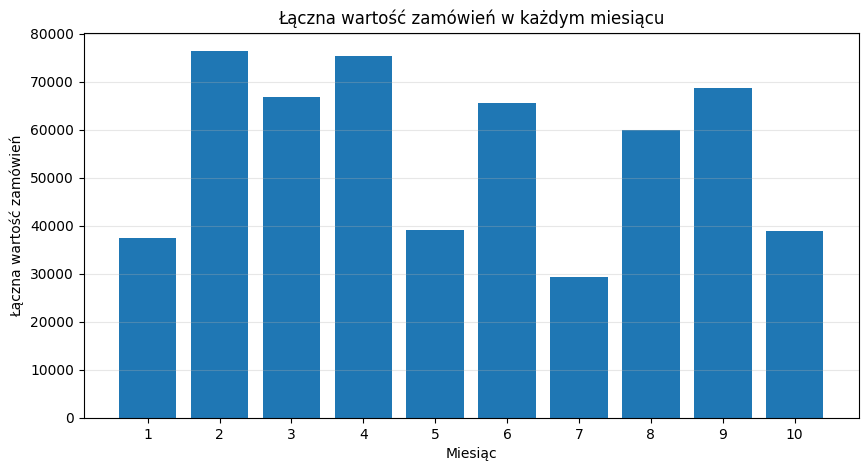

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(wartosc_miesiac["miesiac"], wartosc_miesiac["wartosc_zamowienia"])

plt.xlabel("Miesiąc")
plt.ylabel("Łączna wartość zamówień")
plt.title("Łączna wartość zamówień w każdym miesiącu")
plt.xticks(wartosc_miesiac["miesiac"])
plt.grid(axis="y", alpha=0.3)

plt.show()

In [26]:
df_clean.to_csv("zamowienia_clean.csv", index=False)

print("Zapisano plik zamowienia_clean.csv")

Zapisano plik zamowienia_clean.csv


In [27]:
sprawdzenie = pd.read_csv("zamowienia_clean.csv")
sprawdzenie.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email,wartosc_zamowienia,rok,miesiac,nazwa_dnia,email_poprawny
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila,399.98,2025,6,Friday,False
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00,2025-04-09,marta@gmail.com,399.00,2025,4,Wednesday,True
2,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1499.00,2025-02-05,anna@gmail.com,1499.00,2025,2,Wednesday,True
3,1006,Magdalena Dąbrowska,Laptop,akcesoria,Warszawa,1,299.99,2025-07-04,tomasz@interia.pl,299.99,2025,7,Friday,True
4,1007,Katarzyna Lewandowska,Monitor,akcesoria,Łódź,1,1499.00,2025-10-11,marta@gmail.com,1499.00,2025,10,Saturday,True
